# Image Preprocessing Methods in Computer Vision and Medical Imaging

This notebook introduces common image preprocessing methods used before segmentation, classification, detection, registration, or measurement tasks.

It focuses on practical and widely used techniques such as:

- resizing and interpolation
- normalization and standardization
- min-max scaling
- histogram equalization
- **CLAHE**
- **gamma correction**
- denoising filters
- smoothing and sharpening
- thresholding and binarization
- color space conversion

The notebook also includes:

- explanations in simple language
- mathematical intuition where useful
- runnable Python examples
- student tasks
- challenges
- a mini-project

---

## Learning Objectives

By the end of this notebook, students should be able to:

1. explain why preprocessing is needed
2. apply several preprocessing methods to an image
3. compare outputs visually
4. decide which preprocessing method is suitable for a given problem
5. design a small preprocessing pipeline for a real task

## Why Preprocessing Matters

Raw images often contain problems such as:

- poor contrast
- uneven illumination
- sensor noise
- irrelevant background
- different image sizes
- differences in brightness between devices
- low visibility of important structures

Preprocessing attempts to improve image quality or make the data more consistent before the main algorithm is applied.

For example:

- in **medical imaging**, preprocessing may make lesions, vessels, bones, or organs more visible
- in **document analysis**, it may improve text readability
- in **general computer vision**, it may reduce noise and normalize inputs for deep learning

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except ModuleNotFoundError:
    print("google.colab is not available; skipping Drive mount.")
except Exception as error:
    print(f"Could not mount Google Drive: {error}")

ModuleNotFoundError: No module named 'google'

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)

def show_gray(img, title="Image"):
    plt.figure()
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_color(img, title="Image"):
    plt.figure()
    if len(img.shape) == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def compare_images(images, titles, cmap="gray", cols=3, figsize=(16, 10)):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(rows, cols, i)
        if len(img.shape) == 2:
            plt.imshow(img, cmap=cmap)
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def plot_histogram(img, title="Histogram"):
    plt.figure(figsize=(7, 4))
    plt.hist(img.ravel(), bins=256, range=[0, 256])
    plt.title(title)
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.show()

## Step 1: Load an Example Image

Use your own image if you want.  
Update the file path below.

This notebook assumes a grayscale workflow for several examples because preprocessing concepts are easier to see in grayscale. Later, a color example is also included.

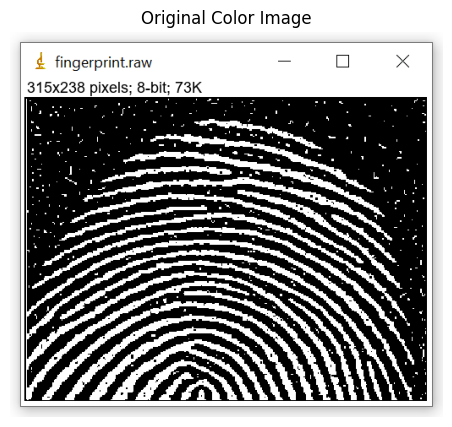

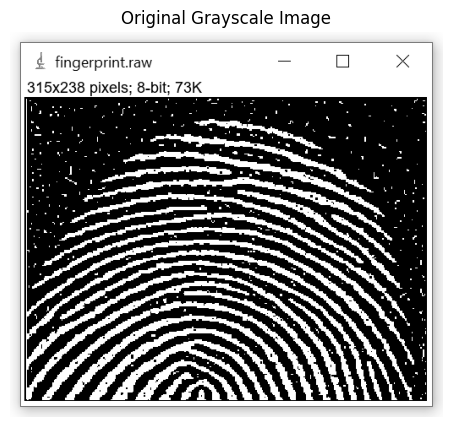

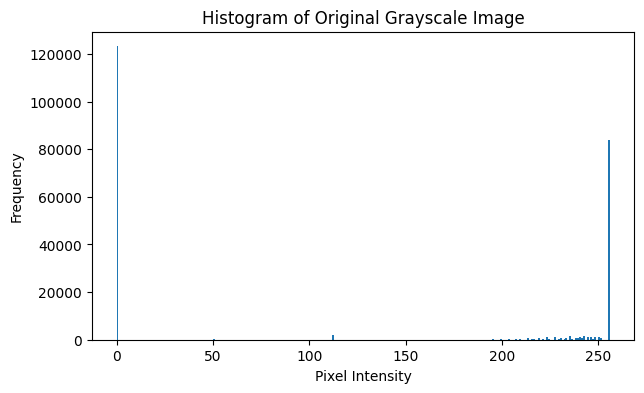

In [5]:
# Replace with your image path
image_path = "finger.png"

img_color = cv2.imread(image_path)

if img_color is None:
    print("Image not found. Please place 'finger.png' in the same folder or change the path.")
else:
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    show_color(img_color, "Original Color Image")
    show_gray(img_gray, "Original Grayscale Image")
    plot_histogram(img_gray, "Histogram of Original Grayscale Image")

## 1. Resizing

Images in datasets often have different sizes. Many machine learning and deep learning pipelines require a fixed input size.

### Common interpolation methods

- `INTER_NEAREST`: fastest, but can look blocky
- `INTER_LINEAR`: common default
- `INTER_CUBIC`: smoother, often better for enlarging
- `INTER_AREA`: often good for shrinking

### Why it matters

Resizing changes:

- image resolution
- visible detail
- edge sharpness
- computational cost

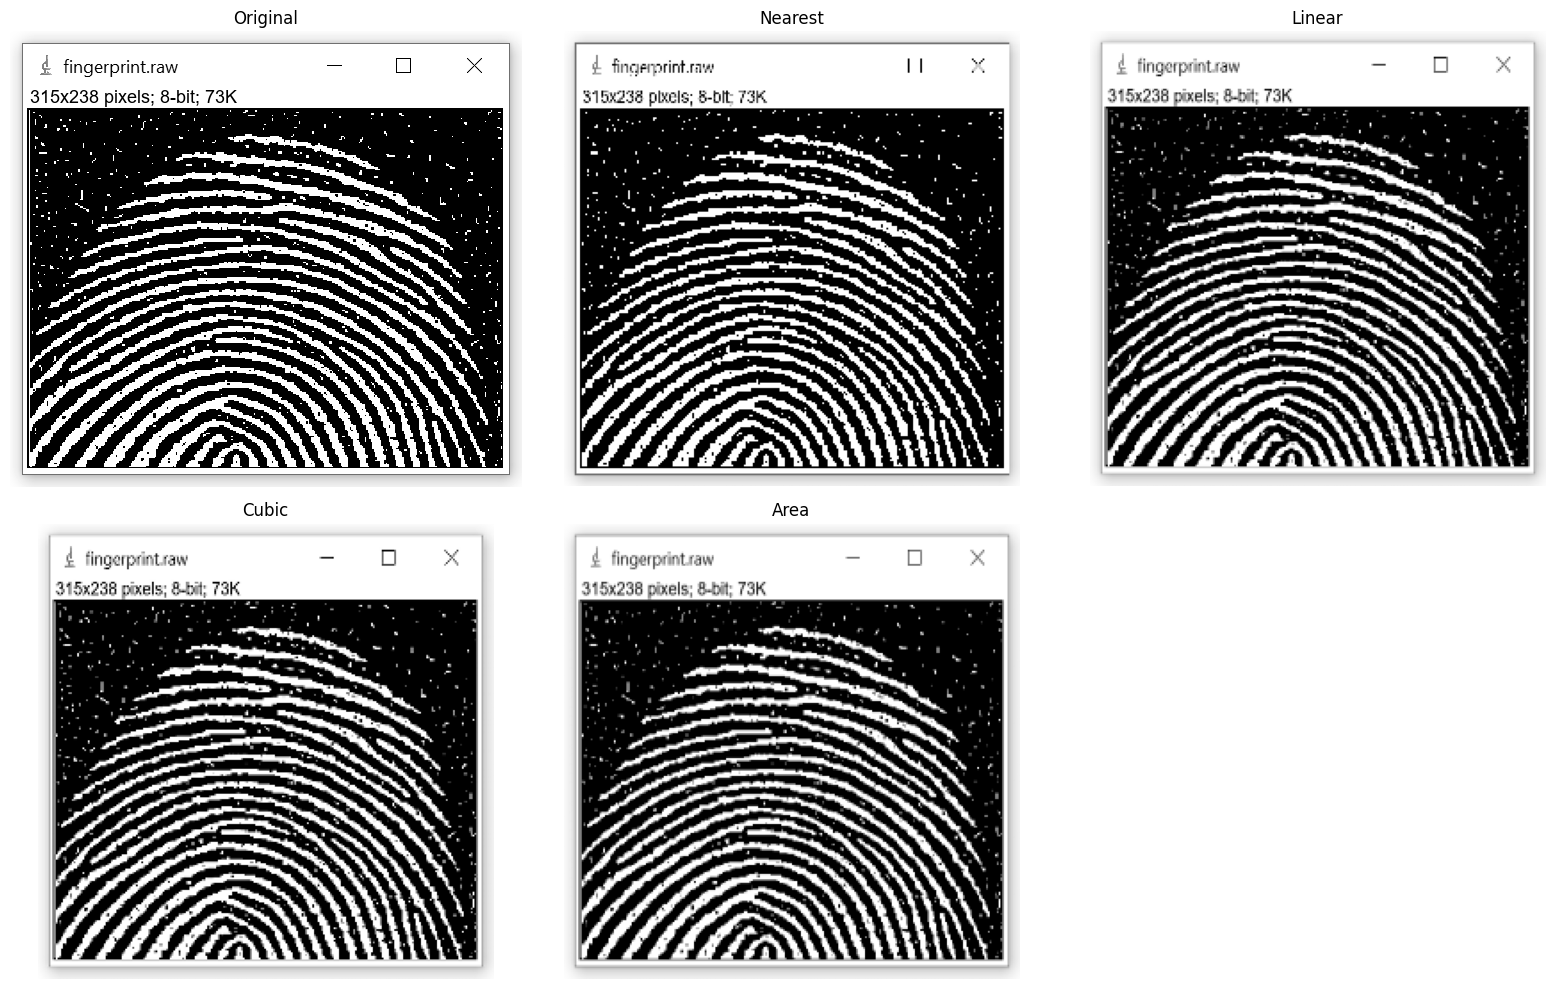

In [6]:
if img_color is not None:
    resized_nearest = cv2.resize(img_gray, (256, 256), interpolation=cv2.INTER_NEAREST)
    resized_linear = cv2.resize(img_gray, (256, 256), interpolation=cv2.INTER_LINEAR)
    resized_cubic = cv2.resize(img_gray, (256, 256), interpolation=cv2.INTER_CUBIC)
    resized_area = cv2.resize(img_gray, (256, 256), interpolation=cv2.INTER_AREA)

    compare_images(
        [img_gray, resized_nearest, resized_linear, resized_cubic, resized_area],
        ["Original", "Nearest", "Linear", "Cubic", "Area"],
        cols=3
    )

### Task 1
Resize the image to:

- `128 x 128`
- `512 x 512`

Then compare how much detail is lost or preserved.

### Challenge 1
Which interpolation method would you choose for:

1. shrinking a chest X-ray?
2. enlarging a skin lesion image?
3. resizing segmentation masks?

Explain your answer.

## 2. Normalization and Standardization

Pixel intensity values can vary widely.  
Scaling them helps make training more stable in machine learning models.

### Min-Max Normalization

Maps values to a fixed range, often `[0, 1]`.

$$
I_{norm} = \frac{I - I_{min}}{I_{max} - I_{min}}
$$

### Standardization

Centers values around zero and scales by standard deviation.

$$
I_{std} = \frac{I - \mu}{\sigma}
$$

### Why it matters

Useful for:

- neural networks
- intensity consistency
- comparing images from different devices

Original min/max: 0.0 255.0
Min-max normalized min/max: 0.0 1.0
Standardized mean/std: 1.2548346e-08 1.0


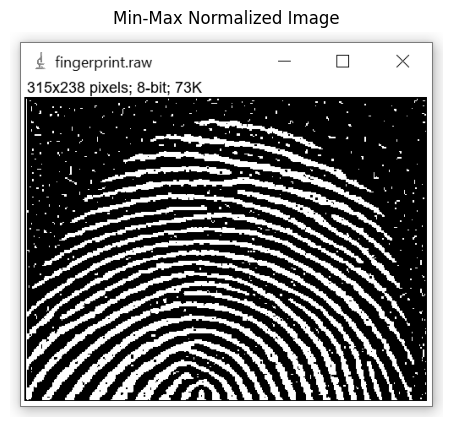

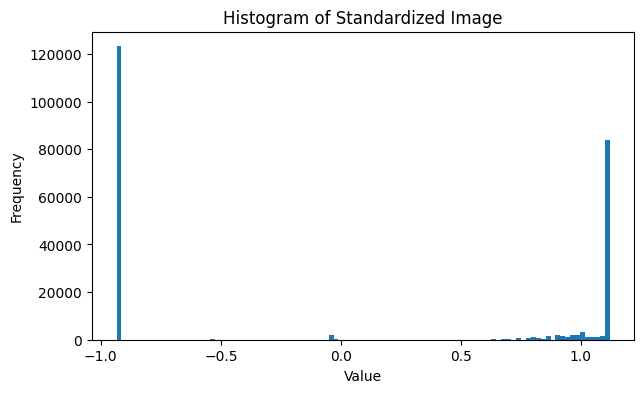

In [7]:
if img_color is not None:
    img_float = img_gray.astype(np.float32)

    minmax = (img_float - img_float.min()) / (img_float.max() - img_float.min() + 1e-8)
    standardized = (img_float - img_float.mean()) / (img_float.std() + 1e-8)

    print("Original min/max:", img_float.min(), img_float.max())
    print("Min-max normalized min/max:", minmax.min(), minmax.max())
    print("Standardized mean/std:", standardized.mean(), standardized.std())

    show_gray(minmax, "Min-Max Normalized Image")
    plt.figure(figsize=(7,4))
    plt.hist(standardized.ravel(), bins=100)
    plt.title("Histogram of Standardized Image")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.show()

### Task 2
Implement min-max normalization manually without using a ready-made function.

### Challenge 2
Why is standardization often used for deep learning, while histogram equalization is often used for visual enhancement?

## 3. Contrast Stretching

Contrast stretching expands a narrow intensity range into a wider one.

If an image is too dark or too flat, this can make structures more visible.

A simple formula is:

$$
I_{out} = \frac{I - a}{b - a} \times 255
$$

where `a` and `b` are the lower and upper intensity bounds.

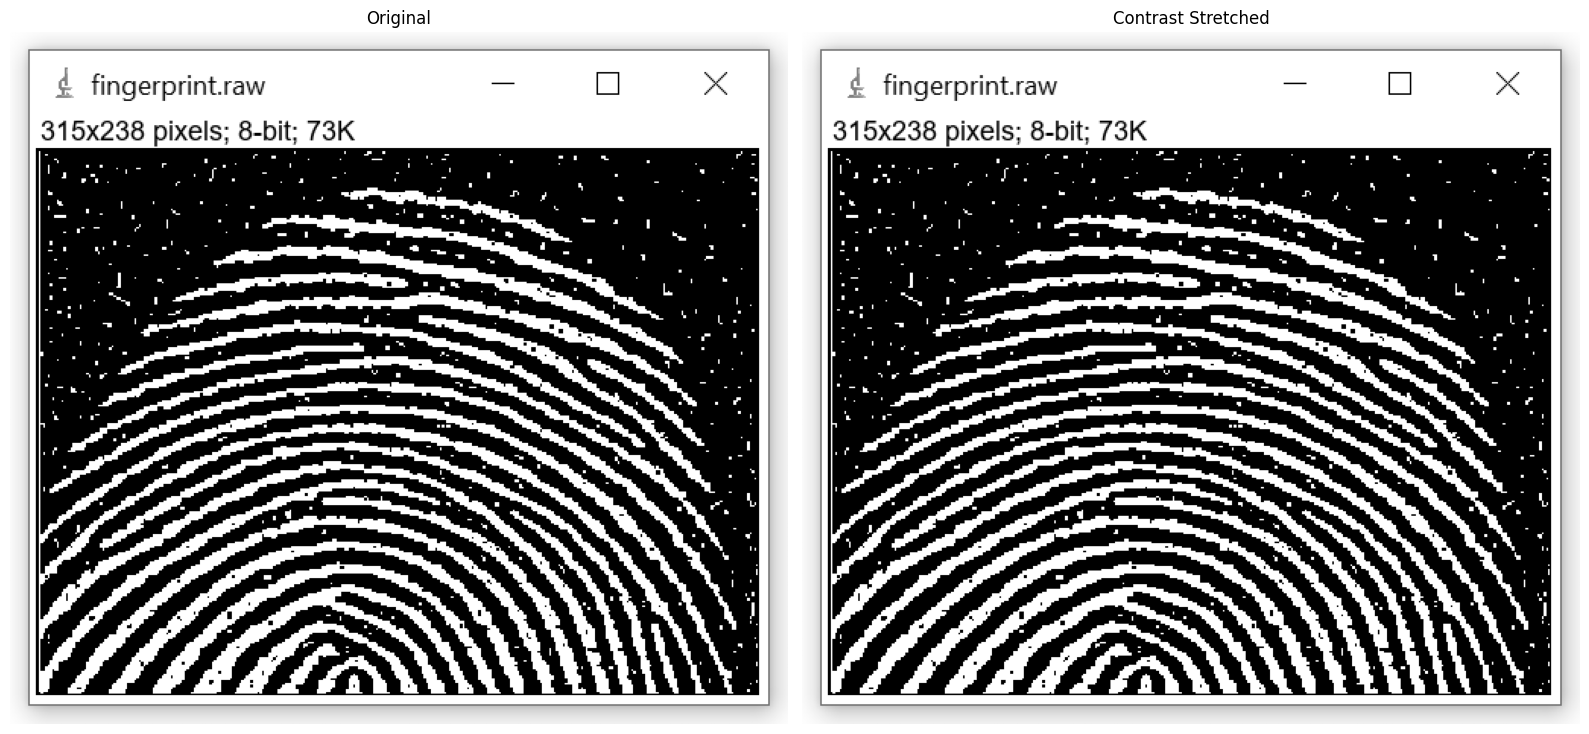

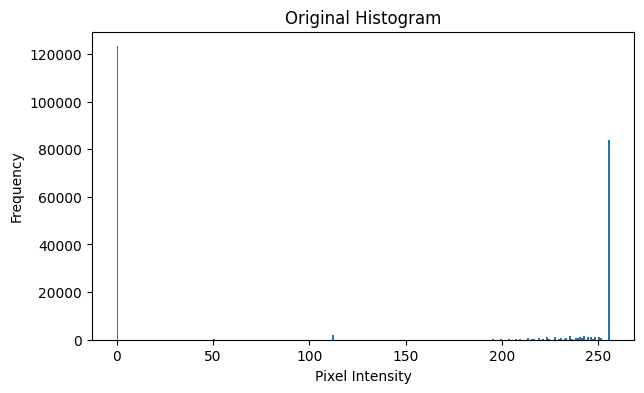

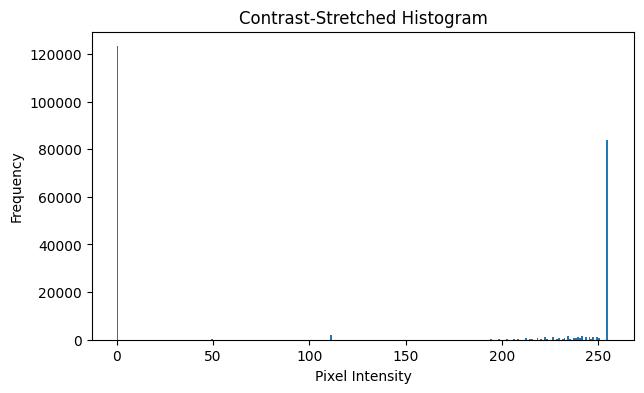

In [8]:
if img_color is not None:
    p2, p98 = np.percentile(img_gray, (2, 98))
    stretched = np.clip((img_gray - p2) * 255.0 / (p98 - p2 + 1e-8), 0, 255).astype(np.uint8)

    compare_images([img_gray, stretched], ["Original", "Contrast Stretched"], cols=2)
    plot_histogram(img_gray, "Original Histogram")
    plot_histogram(stretched, "Contrast-Stretched Histogram")

### Task 3
Try different percentile pairs, such as:

- 1 and 99
- 5 and 95
- 10 and 90

Observe the effect.

### Challenge 3
What happens if the percentile range is too narrow?

## 4. Histogram Equalization

Histogram equalization redistributes pixel intensities so that the histogram becomes more spread out.

This often improves global contrast.

### Advantages

- simple
- fast
- improves low-contrast images

### Limitations

- may over-enhance noise
- may make some regions look unnatural
- not always good for non-uniform lighting

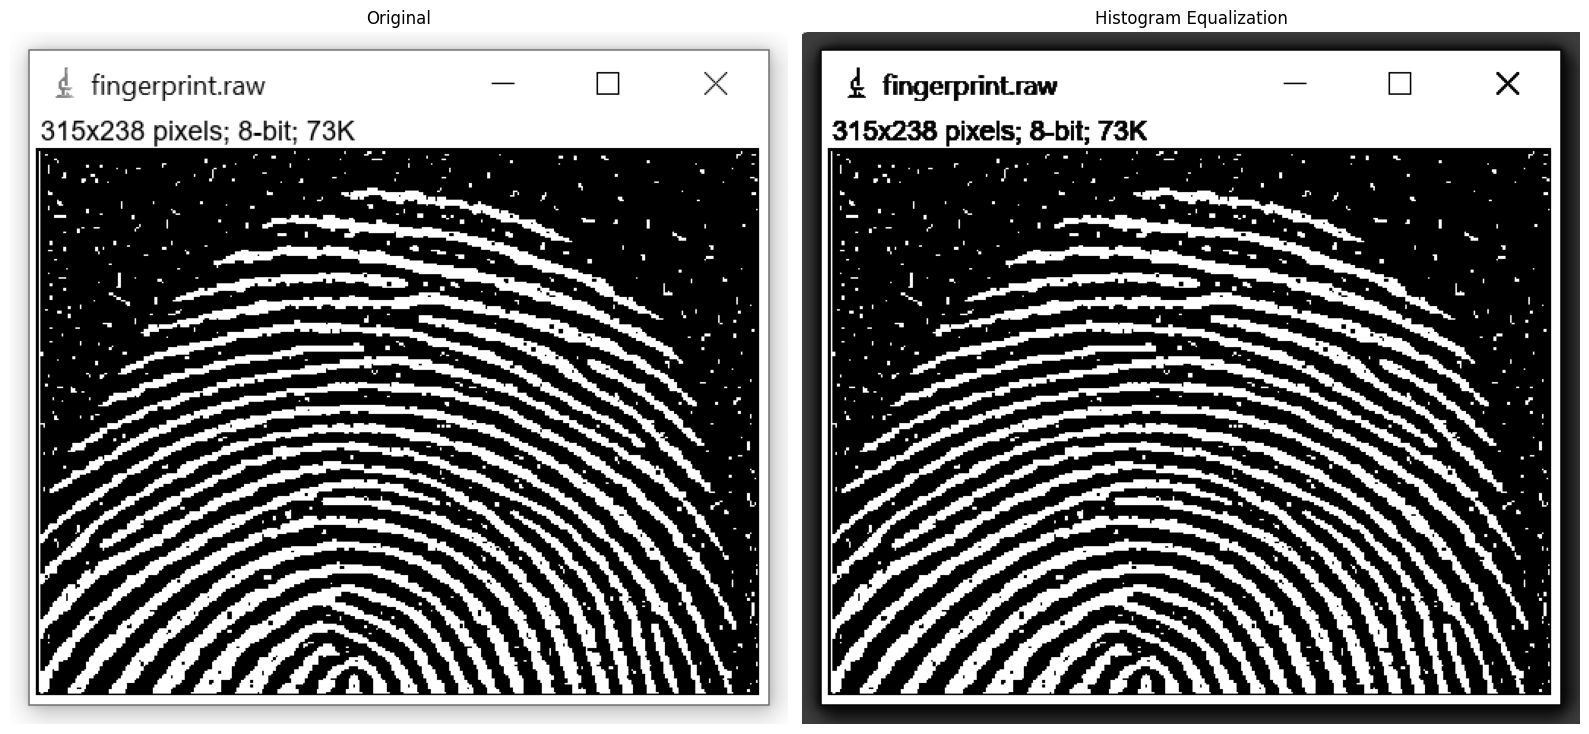

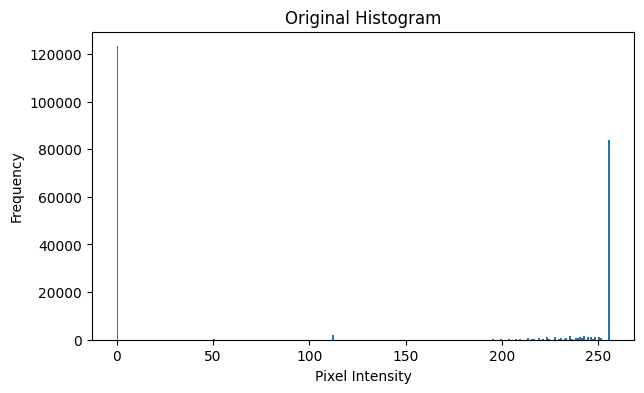

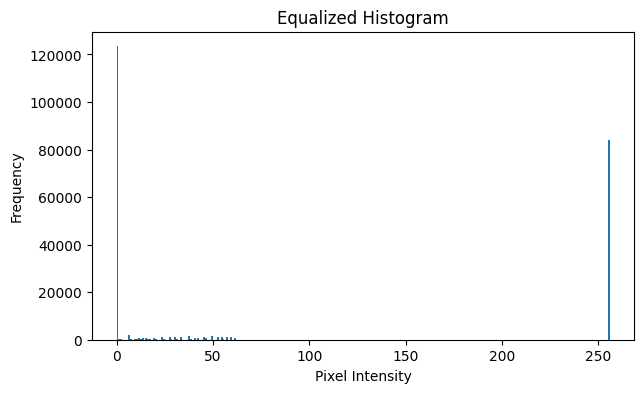

In [9]:
if img_color is not None:
    hist_eq = cv2.equalizeHist(img_gray)

    compare_images([img_gray, hist_eq], ["Original", "Histogram Equalization"], cols=2)
    plot_histogram(img_gray, "Original Histogram")
    plot_histogram(hist_eq, "Equalized Histogram")

### Task 4
Compare histogram equalization with contrast stretching.  
Which one looks more natural on your image?

### Challenge 4
Why can global histogram equalization fail in images with very bright and very dark regions at the same time?

## 5. CLAHE (Contrast Limited Adaptive Histogram Equalization)

**CLAHE** improves local contrast instead of only global contrast.

It works by:

1. dividing the image into small tiles
2. applying histogram equalization inside each tile
3. limiting contrast amplification to reduce noise boosting
4. combining the tiles smoothly

This is especially useful for:

- medical images
- X-rays
- retinal images
- low-contrast local structures

### Important parameters

- `clipLimit`: limits over-amplification
- `tileGridSize`: size of local regions

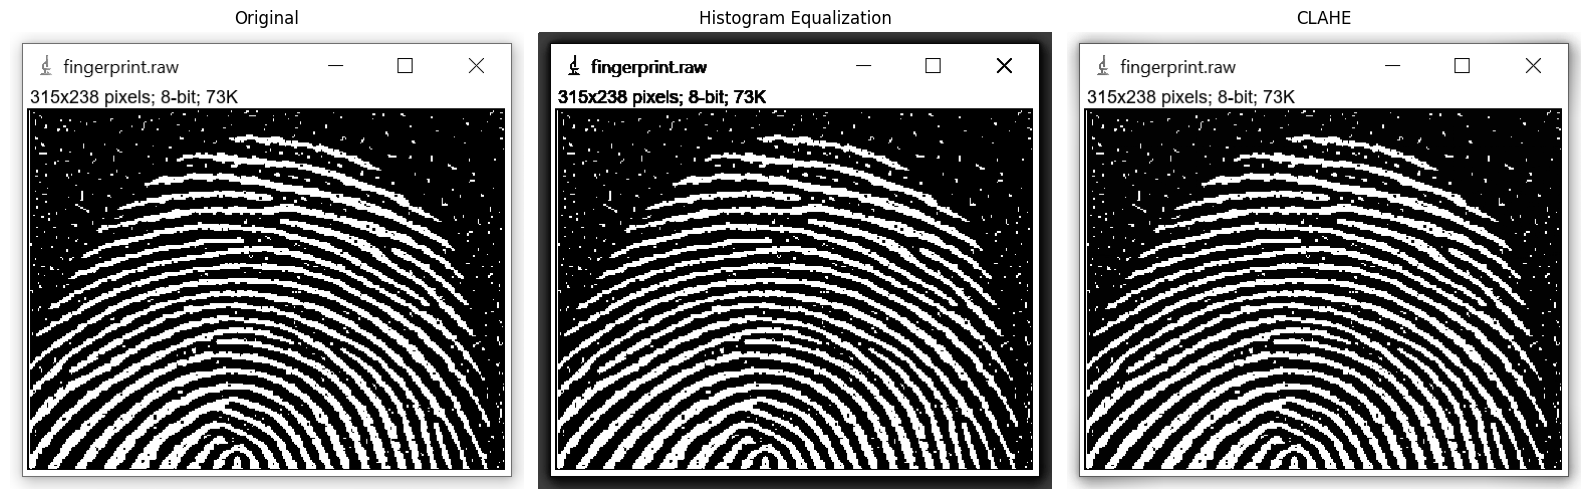

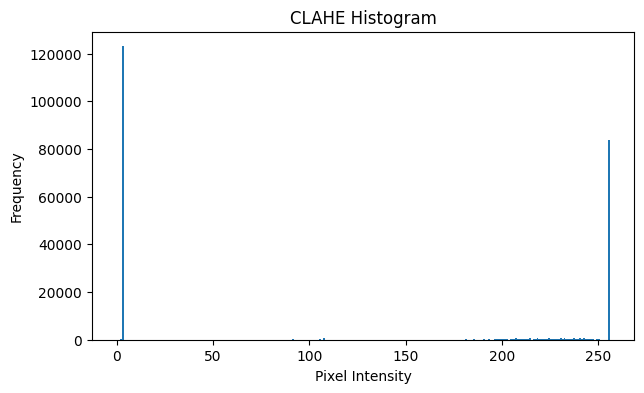

In [10]:
if img_color is not None:
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_gray)

    compare_images(
        [img_gray, hist_eq, img_clahe],
        ["Original", "Histogram Equalization", "CLAHE"],
        cols=3
    )
    plot_histogram(img_clahe, "CLAHE Histogram")

### Task 5
Try these combinations:

- `clipLimit=2.0`, `tileGridSize=(8,8)`
- `clipLimit=4.0`, `tileGridSize=(8,8)`
- `clipLimit=2.0`, `tileGridSize=(16,16)`

Describe how local contrast changes.

### Challenge 5
Why is CLAHE usually preferred over normal histogram equalization in many medical imaging tasks?

## 6. Gamma Correction

Gamma correction changes brightness in a nonlinear way.

The formula is:

$$
I_{out} = c \cdot I^{\gamma}
$$

When images are normalized to `[0,1]`:

- `gamma < 1` makes dark regions brighter
- `gamma > 1` makes the image darker

### Why it matters

Useful when:

- dark structures need enhancement
- illumination is poor
- subtle details are hidden in shadows

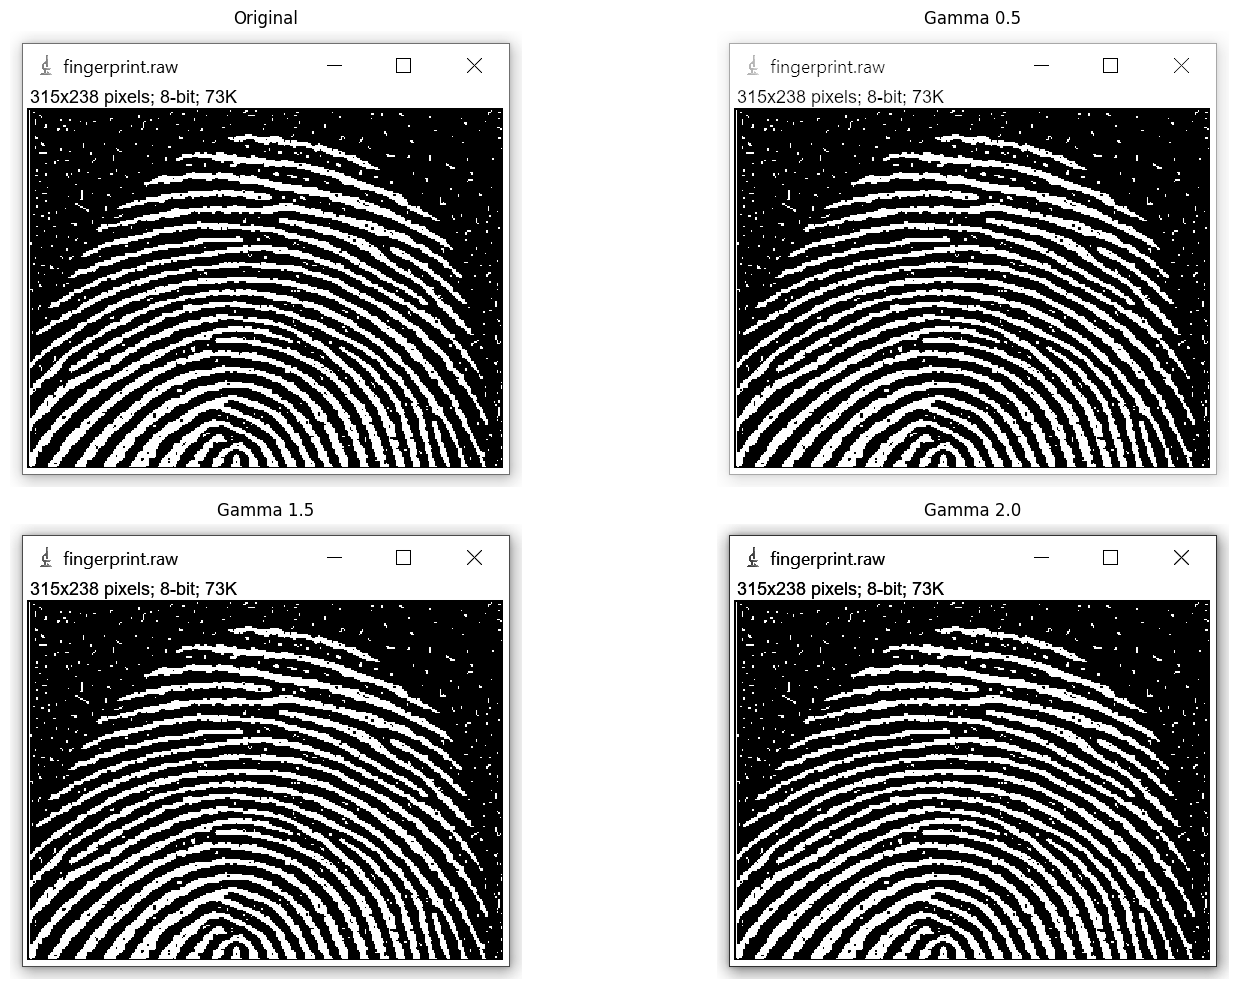

In [11]:
if img_color is not None:
    def gamma_correction(image, gamma=1.0):
        image_norm = image / 255.0
        corrected = np.power(image_norm, gamma)
        corrected = np.clip(corrected * 255, 0, 255).astype(np.uint8)
        return corrected

    gamma_05 = gamma_correction(img_gray, gamma=0.5)
    gamma_15 = gamma_correction(img_gray, gamma=1.5)
    gamma_20 = gamma_correction(img_gray, gamma=2.0)

    compare_images(
        [img_gray, gamma_05, gamma_15, gamma_20],
        ["Original", "Gamma 0.5", "Gamma 1.5", "Gamma 2.0"],
        cols=2
    )

### Task 6
Test gamma values:

- `0.3`
- `0.8`
- `1.2`
- `2.5`

Which value best reveals dark structures in your image?

### Challenge 6
Explain the difference between gamma correction and simple brightness addition.

## 7. Log Transformation

Log transformation expands dark pixel values and compresses bright values.

A common form is:

$$
I_{out} = c \cdot \log(1 + I)
$$

This can help reveal details in darker regions.

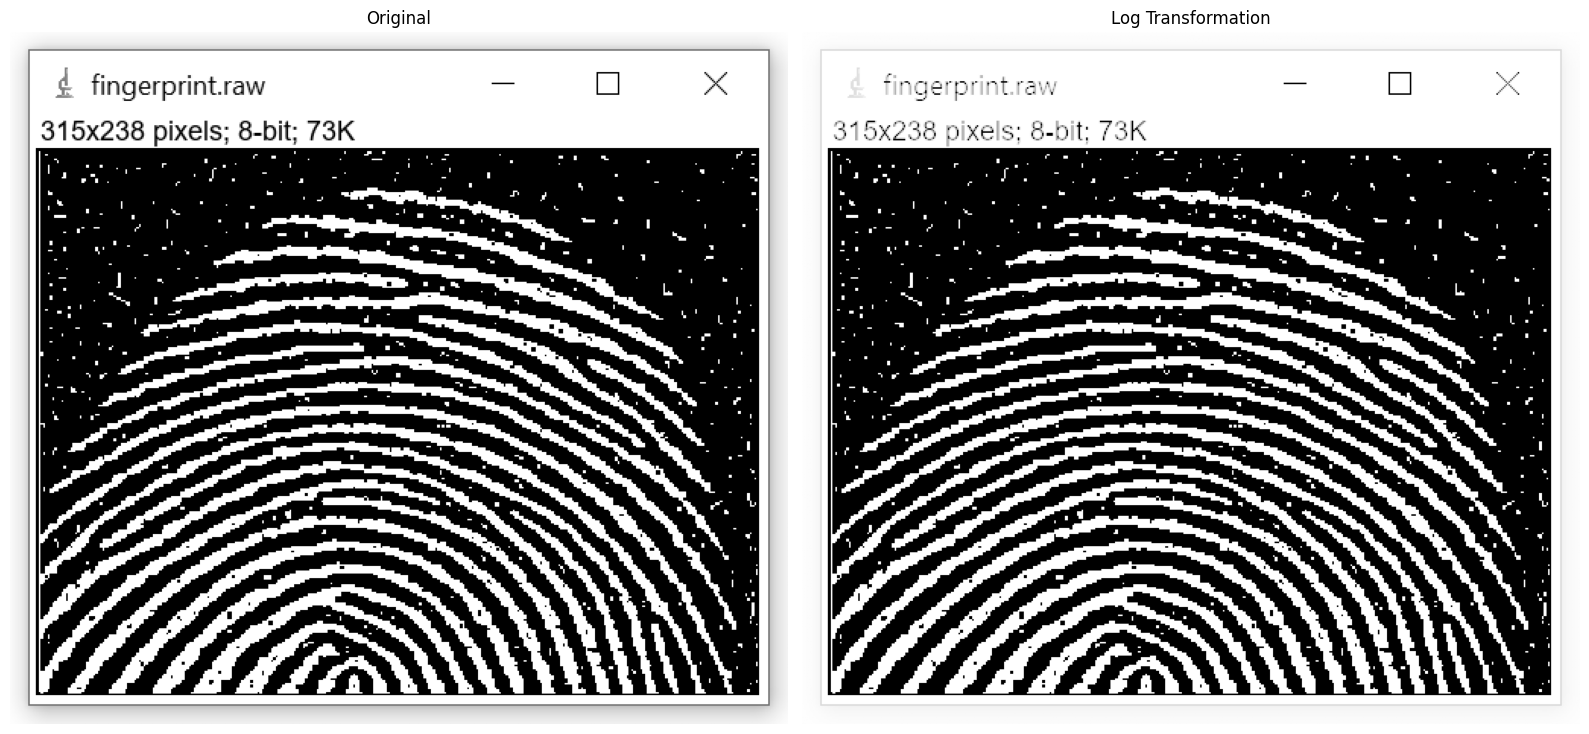

In [12]:
if img_color is not None:
    img_float = img_gray.astype(np.float32)
    c = 255 / np.log(1 + np.max(img_float))
    log_img = c * np.log(1 + img_float)
    log_img = np.clip(log_img, 0, 255).astype(np.uint8)

    compare_images([img_gray, log_img], ["Original", "Log Transformation"], cols=2)

### Task 7
Compare log transformation with gamma correction using `gamma=0.5`.

### Challenge 7
Which one gives more control over enhancement of dark regions?

## 8. Denoising and Smoothing Filters

Noise is common in many real images.

Common denoising filters include:

- **Gaussian blur**: smooths image using weighted average
- **Median filter**: strong for salt-and-pepper noise
- **Bilateral filter**: smooths while preserving edges

### Trade-off

More smoothing often means:

- less noise
- less detail
- blurrier edges

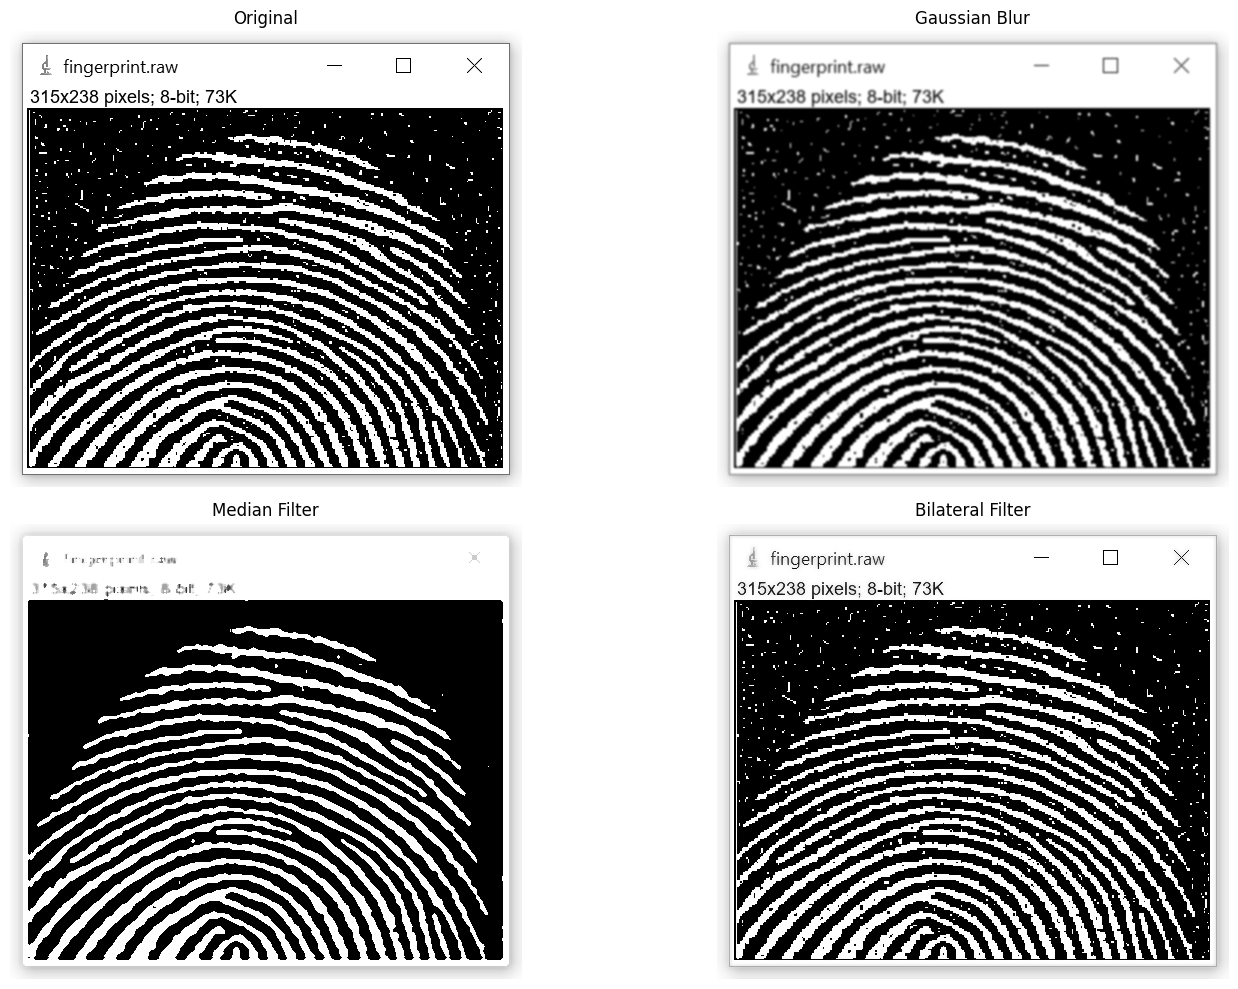

In [13]:
if img_color is not None:
    gaussian = cv2.GaussianBlur(img_gray, (5, 5), 0)
    median = cv2.medianBlur(img_gray, 5)
    bilateral = cv2.bilateralFilter(img_gray, 9, 75, 75)

    compare_images(
        [img_gray, gaussian, median, bilateral],
        ["Original", "Gaussian Blur", "Median Filter", "Bilateral Filter"],
        cols=2
    )

### Task 8
Add synthetic noise to your image, then compare which filter removes it best.

### Challenge 8
Which filter would you choose for:

1. salt-and-pepper noise?
2. noise removal while preserving edges?
3. general smoothing before thresholding?

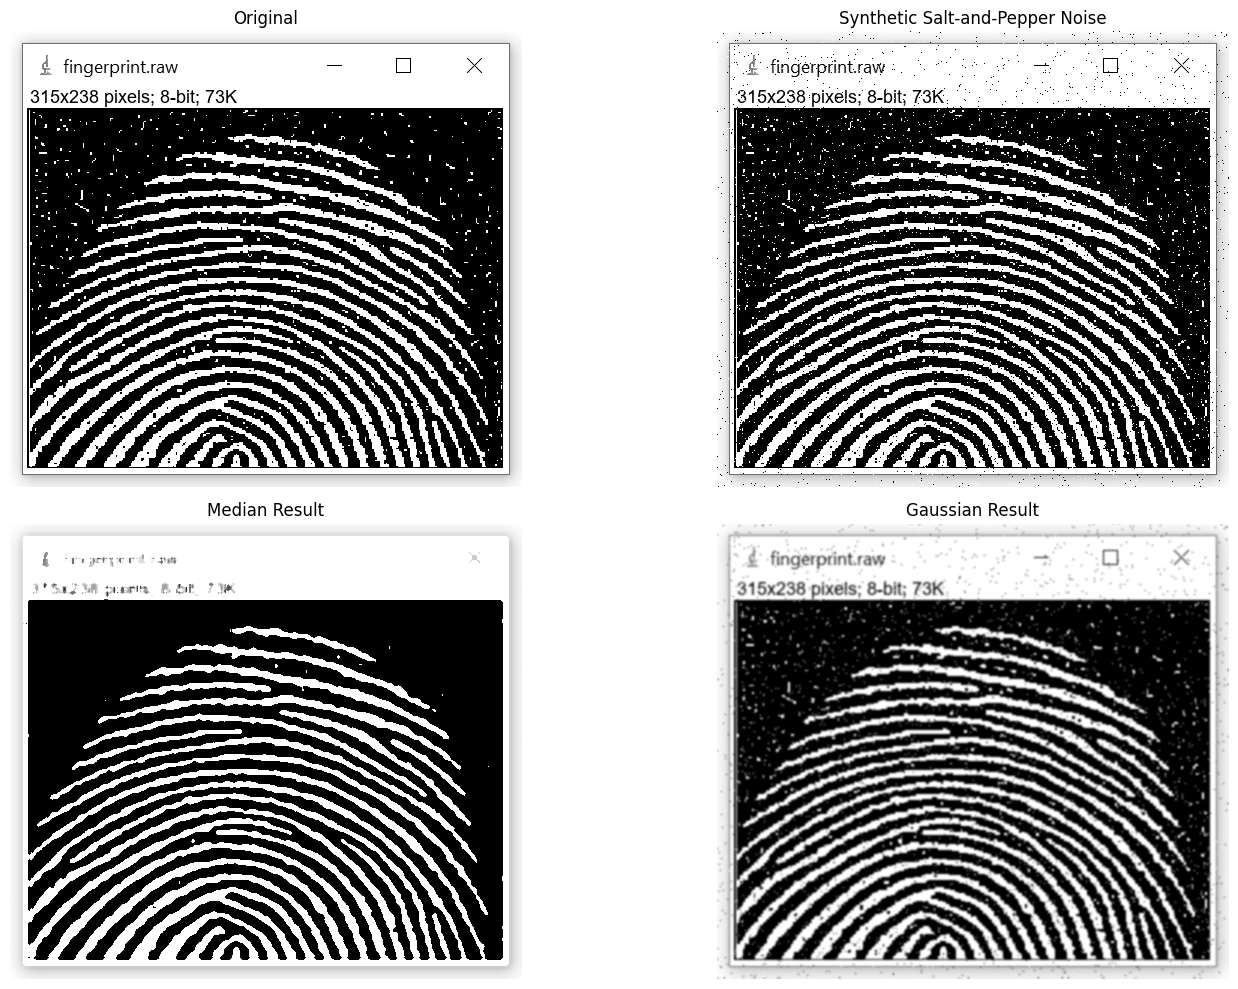

In [14]:
if img_color is not None:
    noisy = img_gray.copy()
    rng = np.random.default_rng(0)
    salt = rng.random(img_gray.shape) < 0.01
    pepper = rng.random(img_gray.shape) < 0.01
    noisy[salt] = 255
    noisy[pepper] = 0

    noisy_median = cv2.medianBlur(noisy, 5)
    noisy_gaussian = cv2.GaussianBlur(noisy, (5,5), 0)

    compare_images(
        [img_gray, noisy, noisy_median, noisy_gaussian],
        ["Original", "Synthetic Salt-and-Pepper Noise", "Median Result", "Gaussian Result"],
        cols=2
    )

## 9. Sharpening

Sharpening enhances edges and fine details.

A common simple method is:

$$
Sharpened = Original + \alpha (Original - Blurred)
$$

This is related to **unsharp masking**.

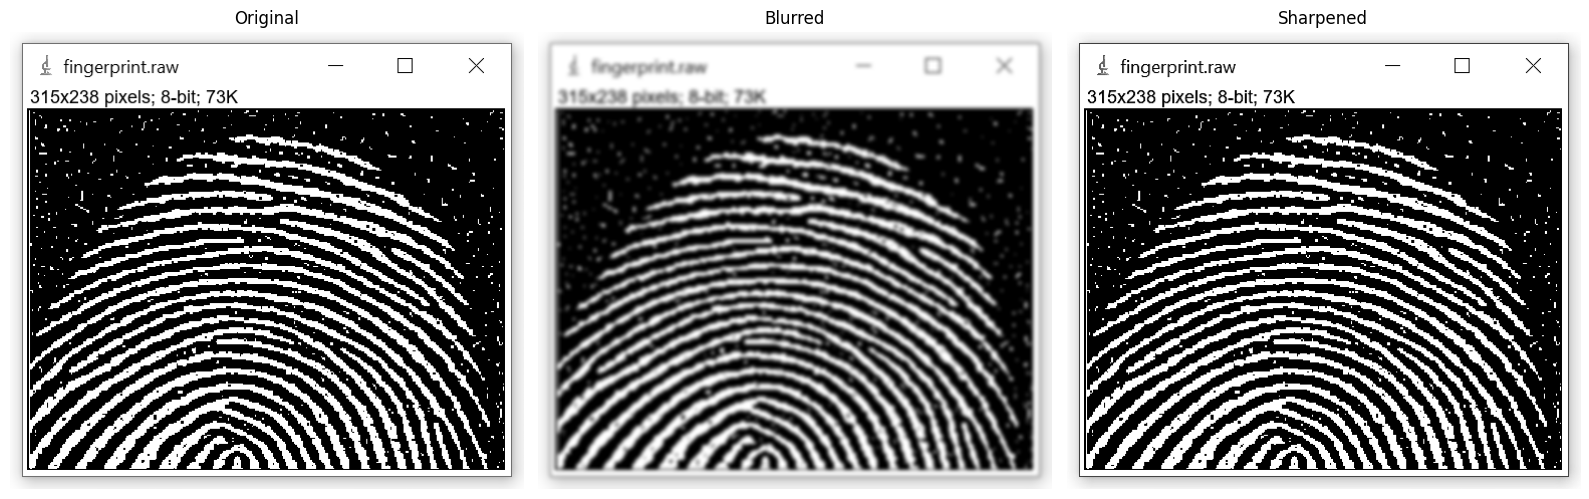

In [15]:
if img_color is not None:
    blurred = cv2.GaussianBlur(img_gray, (9, 9), 2.0)
    sharpened = cv2.addWeighted(img_gray, 1.5, blurred, -0.5, 0)

    compare_images([img_gray, blurred, sharpened], ["Original", "Blurred", "Sharpened"], cols=3)

### Task 9
Change the weights in `cv2.addWeighted` and observe when sharpening becomes too strong.

### Challenge 9
Why can sharpening sometimes hurt segmentation or classification performance?

## 10. Thresholding and Binarization

Thresholding separates foreground from background based on intensity.

### Types

- simple binary threshold
- inverse threshold
- Otsu thresholding
- adaptive thresholding

### Why it matters

Useful for:

- masks
- segmentation
- document binarization
- object extraction

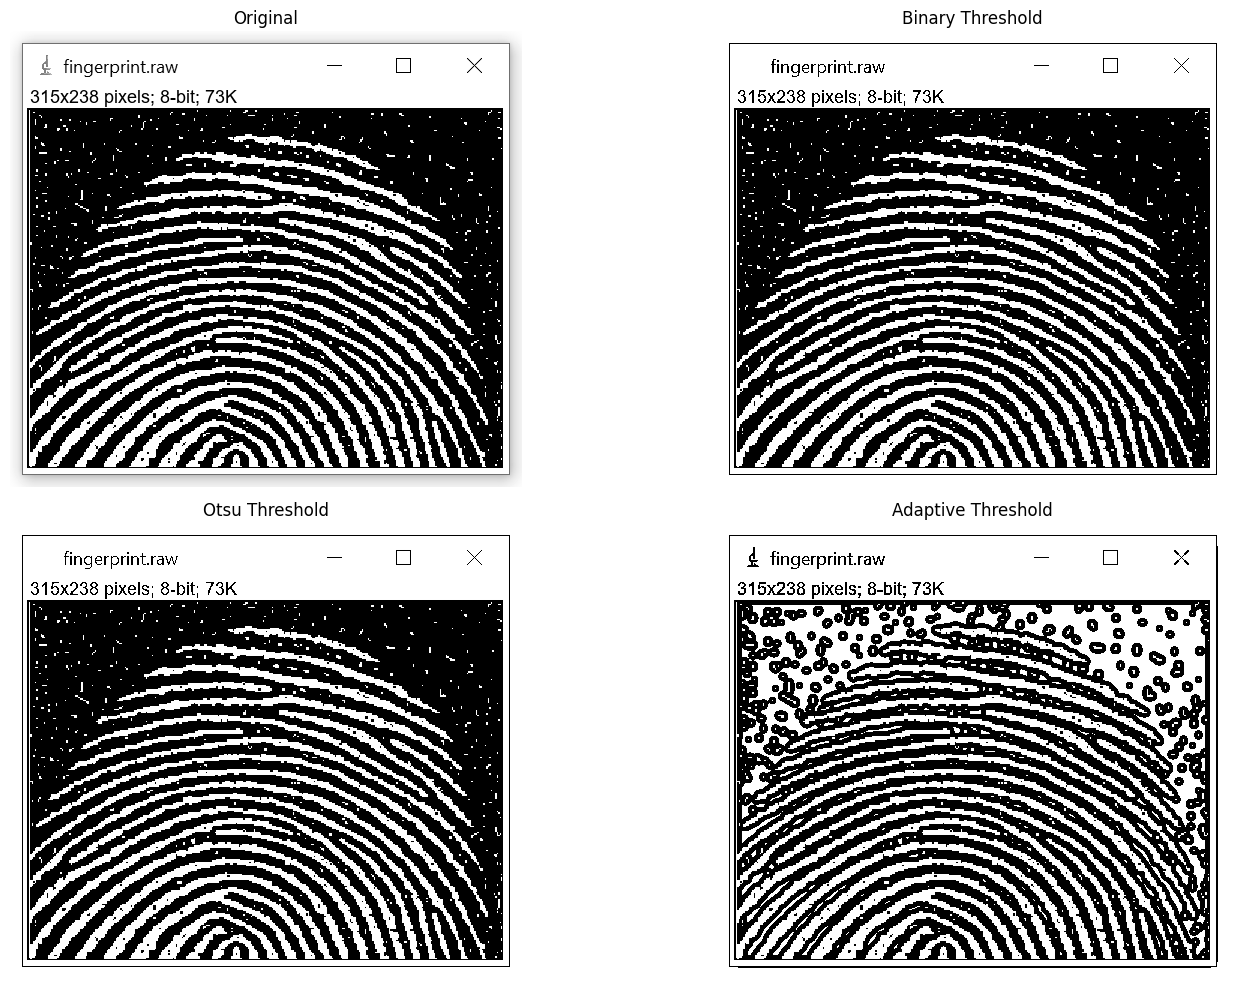

In [16]:
if img_color is not None:
    _, th_binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
    _, th_otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    th_adaptive = cv2.adaptiveThreshold(
        img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )

    compare_images(
        [img_gray, th_binary, th_otsu, th_adaptive],
        ["Original", "Binary Threshold", "Otsu Threshold", "Adaptive Threshold"],
        cols=2
    )

### Task 10
Try threshold values:

- 80
- 100
- 150
- 200

Then compare them with Otsu.

### Challenge 10
Why is adaptive thresholding useful for uneven lighting?

## 11. Color Space Conversion

Some preprocessing works better in a different color space.

Examples:

- **RGB/BGR**: standard color image
- **Grayscale**: simple intensity-based processing
- **HSV**: separates hue, saturation, and brightness
- **LAB**: often useful for illumination and perceptual processing

A common approach is to apply enhancement only to the luminance-related channel.

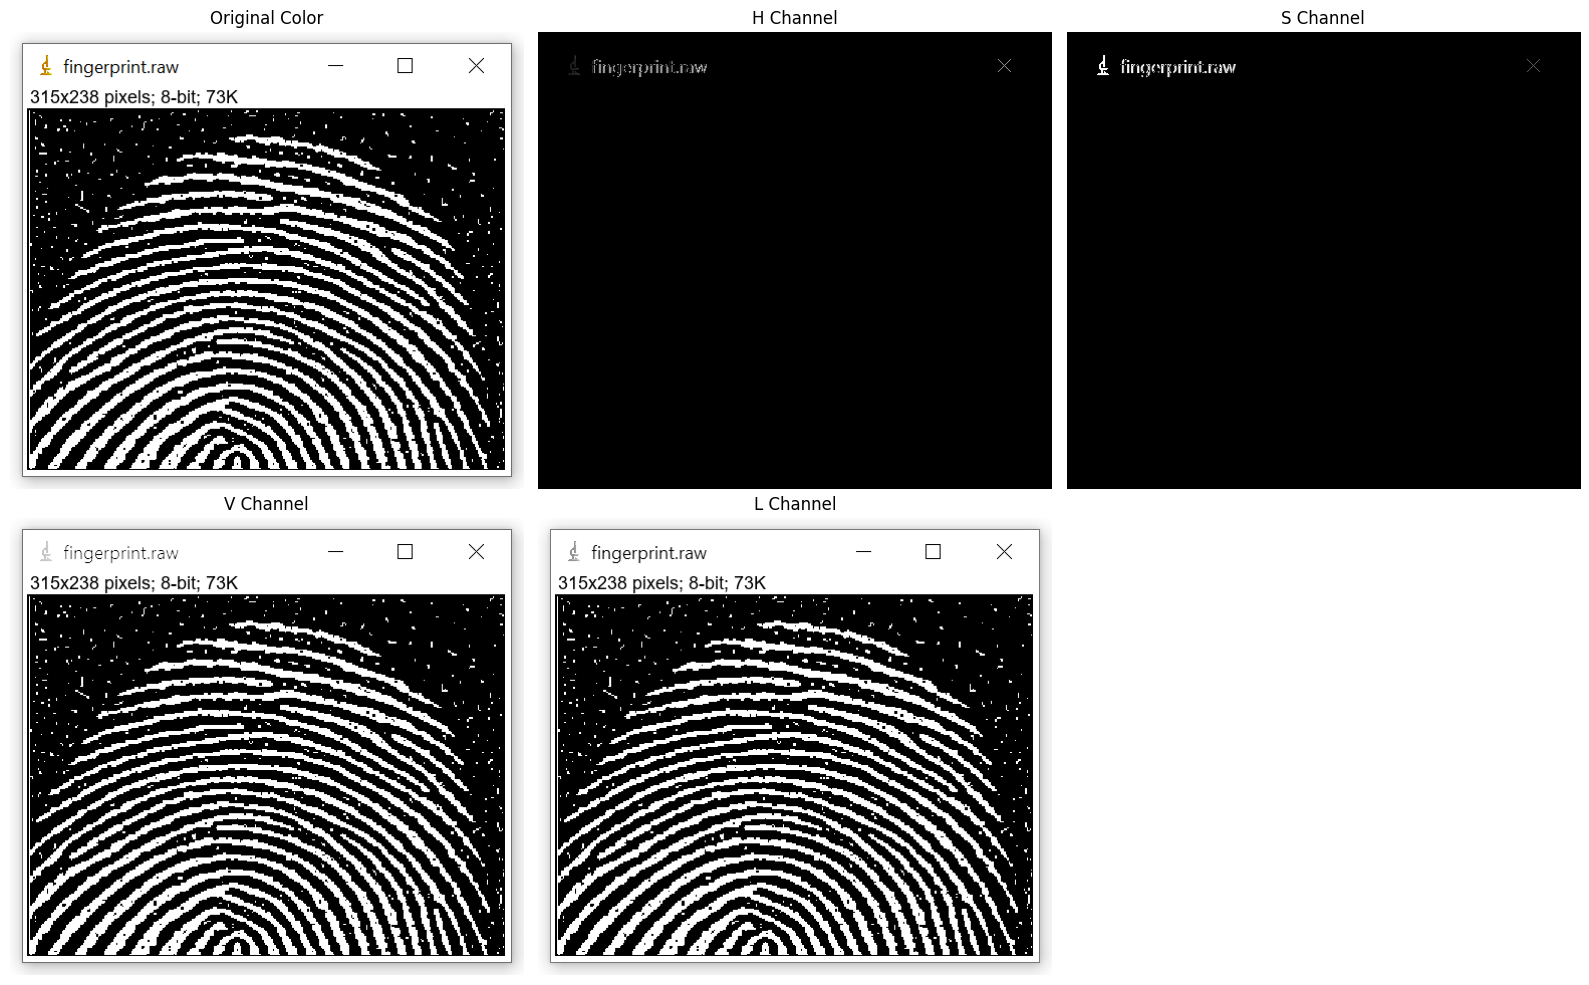

In [17]:
if img_color is not None:
    hsv = cv2.cvtColor(img_color, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(img_color, cv2.COLOR_BGR2LAB)

    h, s, v = cv2.split(hsv)
    l, a, b = cv2.split(lab)

    compare_images(
        [img_color, h, s, v, l],
        ["Original Color", "H Channel", "S Channel", "V Channel", "L Channel"],
        cols=3
    )

### Task 11
Apply CLAHE to:

- grayscale image
- V channel of HSV
- L channel of LAB

Then compare the results.

### Challenge 11
Why can enhancing only a luminance channel be better than enhancing all RGB channels directly?

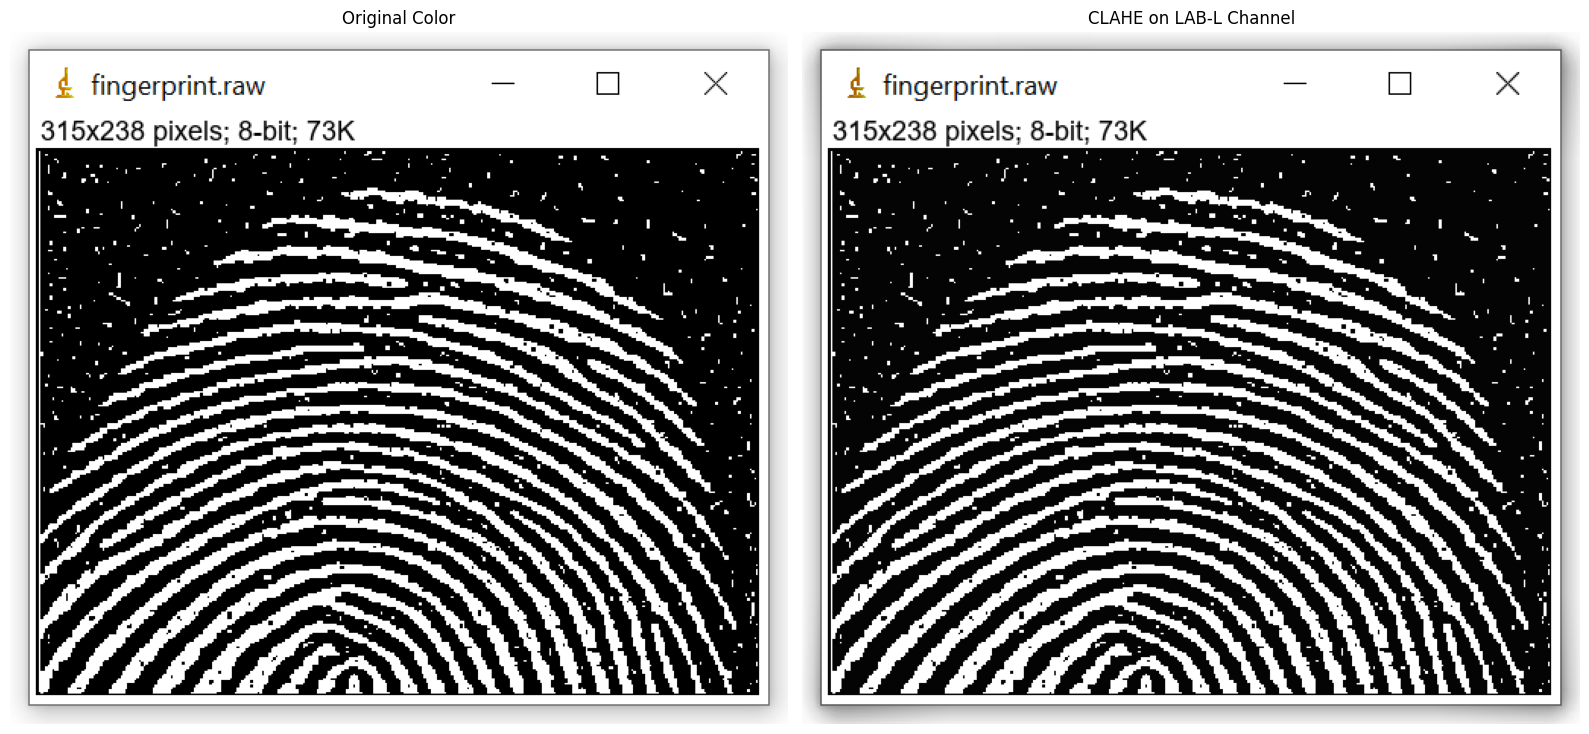

In [18]:
if img_color is not None:
    lab = cv2.cvtColor(img_color, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)

    lab_clahe = cv2.merge((l_clahe, a, b))
    color_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

    compare_images(
        [img_color, color_clahe],
        ["Original Color", "CLAHE on LAB-L Channel"],
        cols=2
    )

## 12. Example of a Small Preprocessing Pipeline

A practical pipeline may combine multiple methods.

For example:

1. load image
2. convert to grayscale
3. resize
4. denoise
5. apply CLAHE
6. threshold
7. save output

This kind of pipeline is common in medical image analysis, OCR, and classical computer vision.

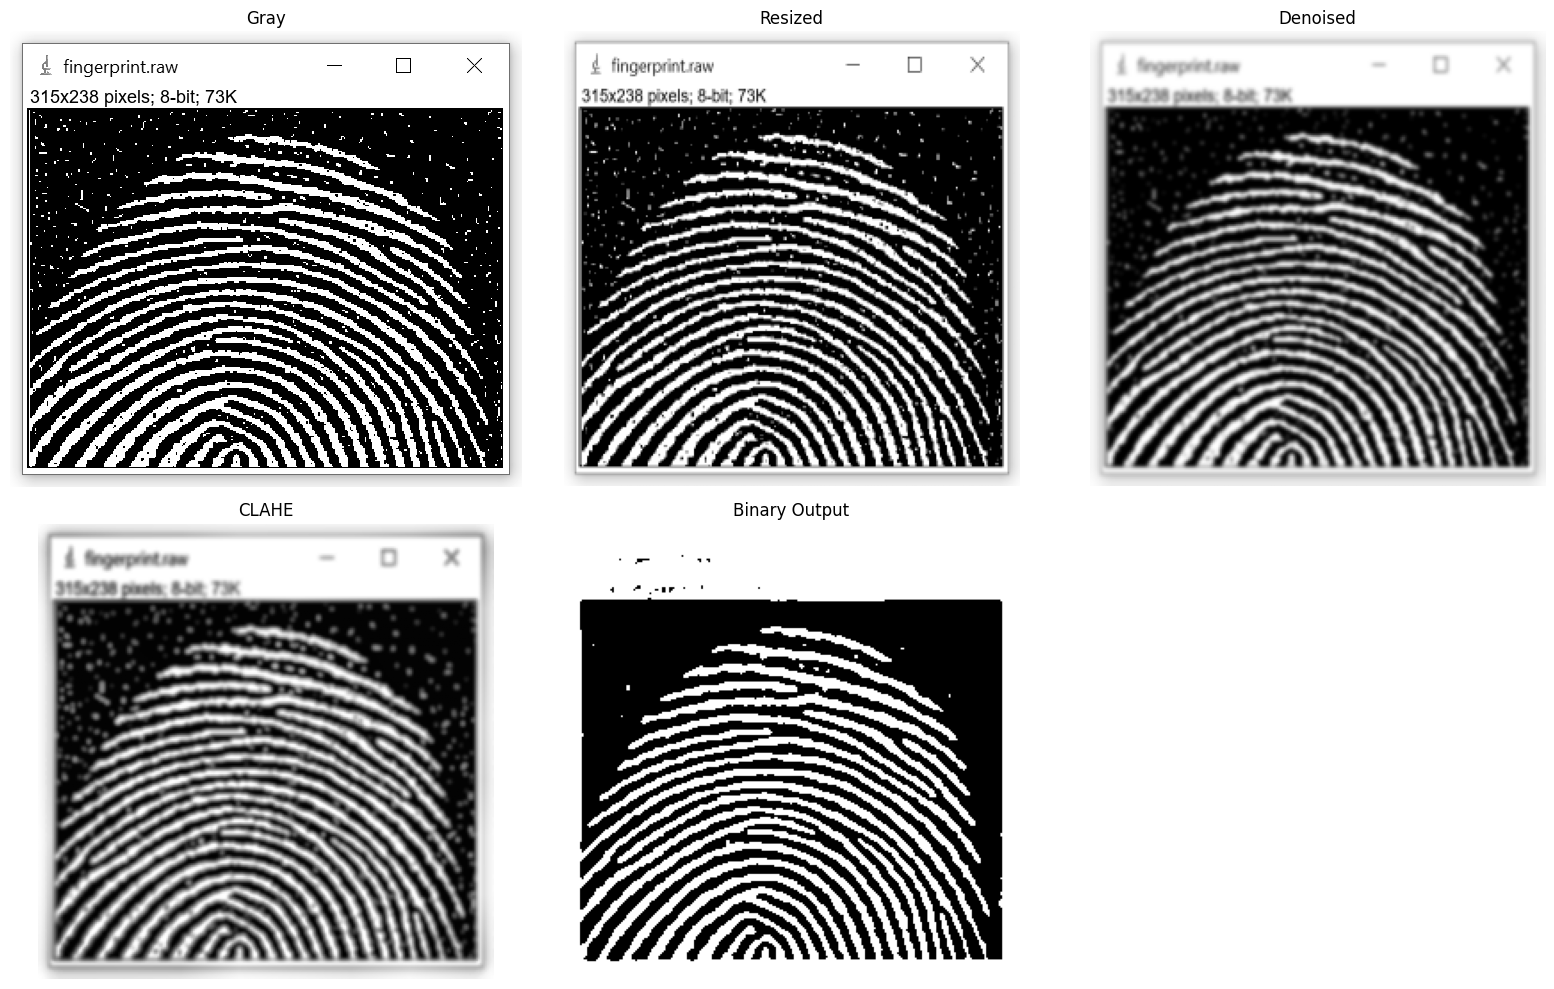

Saved: preprocessed_output.png


In [19]:
if img_color is not None:
    # Step 1: grayscale
    gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    # Step 2: resize
    resized = cv2.resize(gray, (256, 256), interpolation=cv2.INTER_AREA)

    # Step 3: denoise
    denoised = cv2.GaussianBlur(resized, (5, 5), 0)

    # Step 4: CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)

    # Step 5: Otsu threshold
    _, binary = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    compare_images(
        [gray, resized, denoised, enhanced, binary],
        ["Gray", "Resized", "Denoised", "CLAHE", "Binary Output"],
        cols=3
    )

    cv2.imwrite("preprocessed_output.png", binary)
    print("Saved: preprocessed_output.png")

## Choosing the Right Preprocessing Method

There is no single best preprocessing method for every problem.

### General guidance

- use **resizing** when input size must be fixed
- use **normalization** for machine learning pipelines
- use **contrast stretching** for low global contrast
- use **histogram equalization** for quick global contrast enhancement
- use **CLAHE** for local contrast improvement
- use **gamma correction** when dark regions need nonlinear enhancement
- use **median filter** for impulse noise
- use **bilateral filter** when edges should be preserved
- use **thresholding** when extracting foreground objects
- use **color space conversion** when brightness should be processed separately from color

### Important principle

A method that improves visual appearance does **not always** improve model performance.

Always validate preprocessing experimentally.

## Common Mistakes

1. applying too many preprocessing steps and destroying useful detail
2. over-enhancing noise
3. resizing segmentation masks with the wrong interpolation
4. using one preprocessing setting for all datasets without validation
5. choosing methods only by appearance instead of quantitative results
6. forgetting that training and testing must use the same preprocessing pipeline

# Student Exercises

## Basic Exercises

1. Load your own image and convert it to grayscale.
2. Resize it to `256 x 256`.
3. Apply:
   - histogram equalization
   - CLAHE
   - gamma correction with `gamma=0.5`
4. Show the outputs side by side.
5. Write two sentences comparing the results.

## Intermediate Exercises

1. Add salt-and-pepper noise to the image.
2. Remove the noise using:
   - Gaussian blur
   - median filter
   - bilateral filter
3. Compare which method preserves edges better.
4. Apply thresholding after each denoising method.
5. Explain which preprocessing order works best.

## Advanced Exercises

1. Build a preprocessing pipeline for a medical image or grayscale photograph.
2. Try at least three pipeline versions.
3. Compare them visually and quantitatively.
4. If you have a segmentation mask, evaluate IoU or Dice after thresholding.

# Challenges

## Challenge A
Find an image where histogram equalization performs worse than CLAHE.  
Explain why.

## Challenge B
Create a very dark version of an image, then test:

- gamma correction
- log transformation
- CLAHE

Which one recovers detail best?

## Challenge C
Take a color image and compare:

1. applying CLAHE directly to grayscale
2. applying CLAHE to the V channel in HSV
3. applying CLAHE to the L channel in LAB

Which one gives the most natural result?

## Challenge D
Build two pipelines for threshold-based segmentation:

- Pipeline 1: blur -> threshold
- Pipeline 2: CLAHE -> blur -> threshold

Compare the binary masks.

## Challenge E
Choose one real-world application such as:

- document preprocessing
- medical X-ray enhancement
- microscopy cell enhancement
- skin image preprocessing

Then justify your preprocessing choices step by step.

# Mini Project

## Project Title
Design a preprocessing pipeline for one real image.

## Requirements

1. Use one real image.
2. Apply at least **four** preprocessing methods.
3. Include:
   - original image
   - intermediate outputs
   - final output
4. Write a short report answering:
   - What was the problem in the original image?
   - Why did you choose these preprocessing methods?
   - Which step had the biggest effect?
   - What limitations remain?

## Suggested structure

- load image
- inspect histogram
- try contrast enhancement
- try denoising
- test thresholding or sharpening
- compare results
- summarize findings

# Homework Questions

1. What is the difference between global histogram equalization and CLAHE?
2. What happens when gamma is less than 1?
3. Why is median filtering effective for salt-and-pepper noise?
4. Why should segmentation masks usually be resized with nearest-neighbor interpolation?
5. Why should preprocessing be validated rather than chosen only by visual appearance?

---

# Short Answers

**1.** Global histogram equalization enhances contrast using one histogram for the whole image, while CLAHE enhances contrast locally in small tiles and limits over-amplification.

**2.** Gamma less than 1 brightens dark regions more strongly.

**3.** Median filtering replaces each pixel with the median of its neighborhood, which removes isolated extreme values without averaging edges as much as Gaussian blur.

**4.** Nearest-neighbor keeps label values discrete and avoids creating fake intermediate classes.

**5.** Because a visually attractive image may not produce the best quantitative performance for detection, segmentation, or classification.

# Conclusion

Preprocessing is a critical step in image analysis.

Methods such as **CLAHE**, **gamma correction**, **normalization**, **filtering**, and **thresholding** can substantially change what features are visible and what information is preserved.

The correct choice depends on:

- the image type
- the noise characteristics
- the goal of the task
- whether the final system is for visual interpretation or machine learning

The best workflow is not to assume, but to test, compare, and validate.

## Challenge A–E Answers

**Challenge A**
- A good example where CLAHE beats global histogram equalization is a low-contrast medical X-ray or a noisy fingerprint.
- CLAHE improves local contrast and avoids flattening the whole image with one global mapping.

**Challenge B**
- For a very dark image, CLAHE usually recovers detail best overall.
- Gamma correction with `gamma < 1` is also strong, while log transform is useful but less controllable.

**Challenge C**
- For a color image, CLAHE on the LAB `L` channel is usually the most natural choice.
- HSV `V` channel is also good, while grayscale CLAHE is fine only when color is not important.

**Challenge D**
- `blur -> threshold` is usually cleaner when lighting is already fairly uniform.
- `CLAHE -> blur -> threshold` is better when local contrast is weak or illumination is uneven.
- On fingerprint-like images, CLAHE can help ridge visibility but may also increase background noise.

**Challenge E**
- Example application: document preprocessing.
- Suggested pipeline: grayscale -> denoise -> CLAHE -> adaptive threshold.
- Reason: grayscale simplifies processing, denoising reduces speckle, CLAHE boosts faint text, and adaptive threshold handles uneven lighting.

## Solutions to Tasks and Challenges

The cells above already demonstrate the preprocessing methods on `finger.png`. This section records concise answers for the notebook prompts.

### Tasks 1–5

**Task 1**
- Resize to `128 x 128` with `INTER_AREA` for shrinking.
- Resize to `512 x 512` with `INTER_CUBIC` or `INTER_LINEAR` for enlarging.
- Smaller size loses ridge detail; larger size preserves structure but interpolates the ridges.

**Challenge 1**
- Chest X-ray shrinking: `INTER_AREA`
- Skin lesion enlarging: `INTER_CUBIC`
- Segmentation masks: `INTER_NEAREST`
- Reason: preserve intensity averages for shrinking, smooth detail for enlargement, and keep labels discrete for masks.

**Task 2**
```python
img_float = img_gray.astype(np.float32)
minmax = (img_float - img_float.min()) / (img_float.max() - img_float.min() + 1e-8)
```
- This matches the manual min-max normalization already shown in the notebook.

**Challenge 2**
- Standardization helps model training because it centers data and stabilizes gradients.
- Histogram equalization is mainly for visual contrast enhancement, not for making feature distributions easier to optimize.

**Task 3**
- Try percentiles such as `1/99`, `5/95`, and `10/90`.
- `5/95` is usually a good balance on this image.
- Narrower ranges increase contrast more aggressively but can clip detail and amplify noise.

**Task 4**
- On this fingerprint image, contrast stretching usually looks more natural than global histogram equalization.
- Histogram equalization can exaggerate background speckles and make the result look harsher.

**Challenge 4**
- Global histogram equalization can fail when an image contains both bright and dark regions because one global mapping cannot suit every local area.
- It may flatten useful local contrast or over-amplify noise.

**Task 5**
- `clipLimit=2.0, tileGridSize=(8,8)` is a balanced default.
- `clipLimit=4.0` increases local contrast but can also boost noise.
- `tileGridSize=(16,16)` makes the effect smoother and less local.

**Challenge 5**
- CLAHE is preferred in medical imaging because it enhances local contrast while limiting noise amplification.
- It avoids the strong global artifacts that standard histogram equalization can create.

### Tasks 6–11

**Task 6**
- For dark structures, `gamma < 1` works best.
- On this image, `gamma=0.5` is a good compromise, while `0.3` is stronger and more aggressive.

**Challenge 6**
- Gamma correction is nonlinear and controllable.
- Brightness addition is linear and shifts all pixels by a fixed amount.

**Task 7**
- Log transformation is very effective for extremely dark regions because it expands low intensities strongly.
- Gamma correction gives more control and is easier to tune.
- For this image, `gamma=0.5` and log transform both help, but log is more aggressive on shadows.

**Challenge 7**
- Gamma correction gives more practical control over dark-region enhancement.
- Log transform is useful, but its response is less intuitive to tune.

**Task 8**
- Salt-and-pepper noise: median filter is best.
- Edge-preserving smoothing: bilateral filter is best.
- General smoothing before thresholding: Gaussian blur is a common choice.

**Challenge 8**
1. Salt-and-pepper noise: median filter
2. Preserve edges: bilateral filter
3. General smoothing before thresholding: Gaussian blur
- In this notebook, the median result is the cleanest on impulse noise.

**Task 9**
- Sharpening becomes too strong when halos appear around ridges or when noise and tiny specks become more visible.
- A moderate setting like `1.5 * original - 0.5 * blurred` is usually safer than heavier weights.

**Challenge 9**
- Sharpening can hurt segmentation or classification because it may amplify noise and create false edges.
- That can confuse both thresholding and learned models.

**Task 10**
- Otsu thresholding is a strong automatic baseline for this image.
- Adaptive thresholding is useful when illumination varies, but it can introduce many speckles if the local window is not tuned well.

**Challenge 10**
- Adaptive thresholding works better under uneven lighting because it computes thresholds locally rather than globally.

**Task 11**
- For a real color image, the most natural result usually comes from CLAHE on the `L` channel in LAB, or on the `V` channel in HSV.
- For this grayscale fingerprint image, the grayscale and LAB-L results are effectively the most meaningful.

**Challenge 11**
- Enhancing only a luminance channel avoids hue shifts and color artifacts.
- It changes brightness without distorting the chromatic information.

### Challenges A–E

**Challenge A**
- A low-contrast medical X-ray or a noisy fingerprint is a good example where CLAHE usually performs better than global histogram equalization.
- The reason is that CLAHE improves local contrast while limiting noise blow-up.

**Challenge B**
- For a very dark image, CLAHE usually recovers detail best overall.
- Gamma correction with a low gamma value is also very effective.
- Log transform helps too, but it is often less controlled than gamma + CLAHE.

**Challenge C**
- For a color image, CLAHE on the LAB `L` channel is usually the most natural.
- HSV `V` channel is also reasonable.
- Direct grayscale CLAHE is fine for intensity-only processing, but it discards color information.

**Challenge D**
- `blur -> threshold` usually gives the cleaner mask when the image already has fairly uniform lighting.
- `CLAHE -> blur -> threshold` is better when local contrast is weak or illumination is uneven.
- On a fingerprint-like image, CLAHE may improve ridge visibility but can also strengthen background noise.

**Challenge E**
- Example application: document preprocessing.
- Suggested pipeline: grayscale -> denoise -> CLAHE -> adaptive threshold.
- Why: grayscale simplifies the image, denoising removes speckle, CLAHE boosts faint text, and adaptive threshold handles uneven lighting.

Challenge A: CLAHE versus global histogram equalization


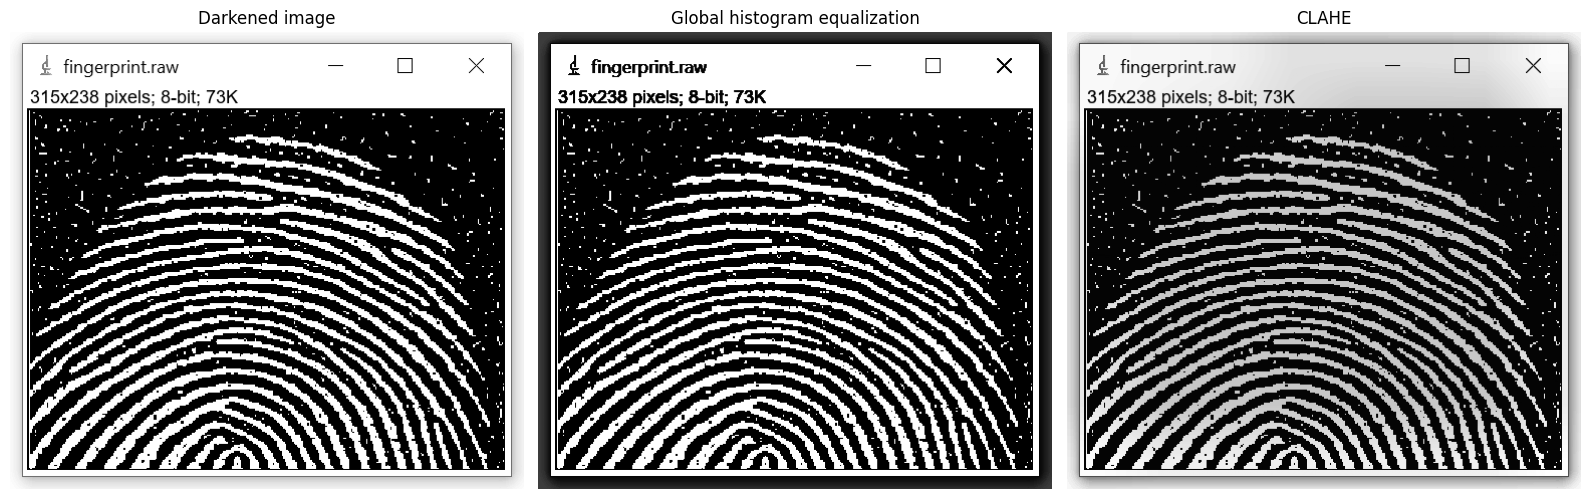

Challenge B: Gamma correction, log transform, and CLAHE on a dark image


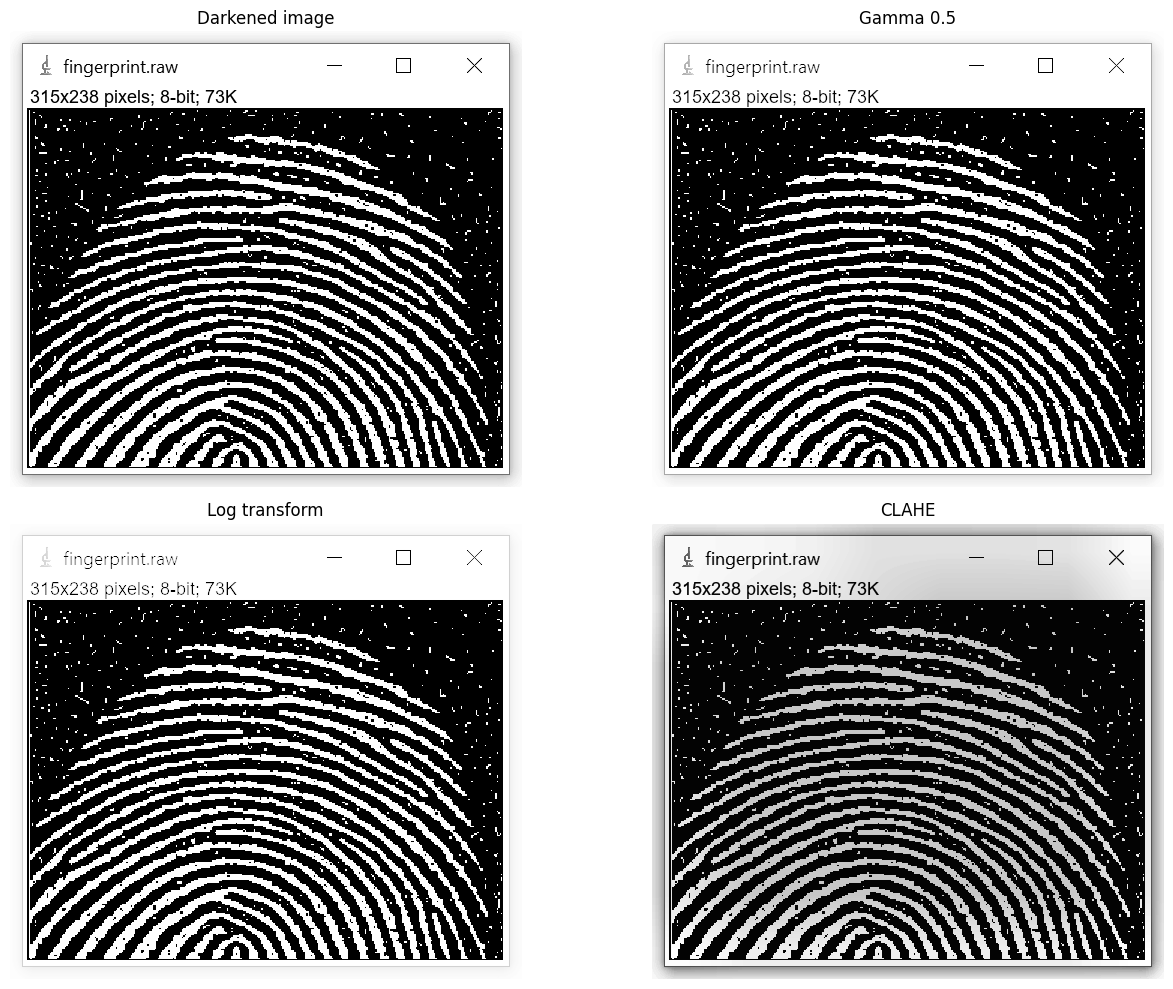

Challenge C: CLAHE on grayscale, HSV-V, and LAB-L channels


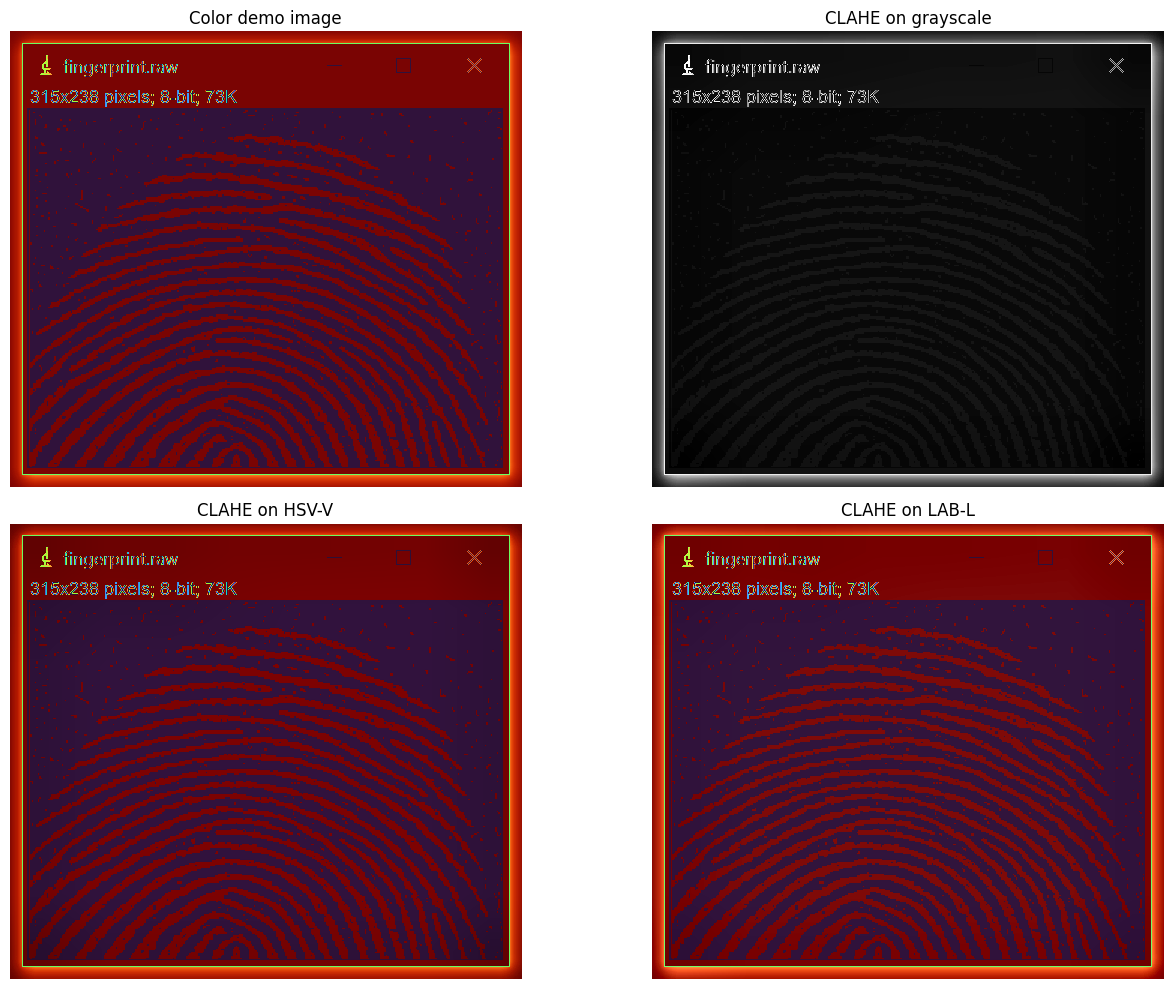

Challenge D: Blur -> threshold versus CLAHE -> blur -> threshold


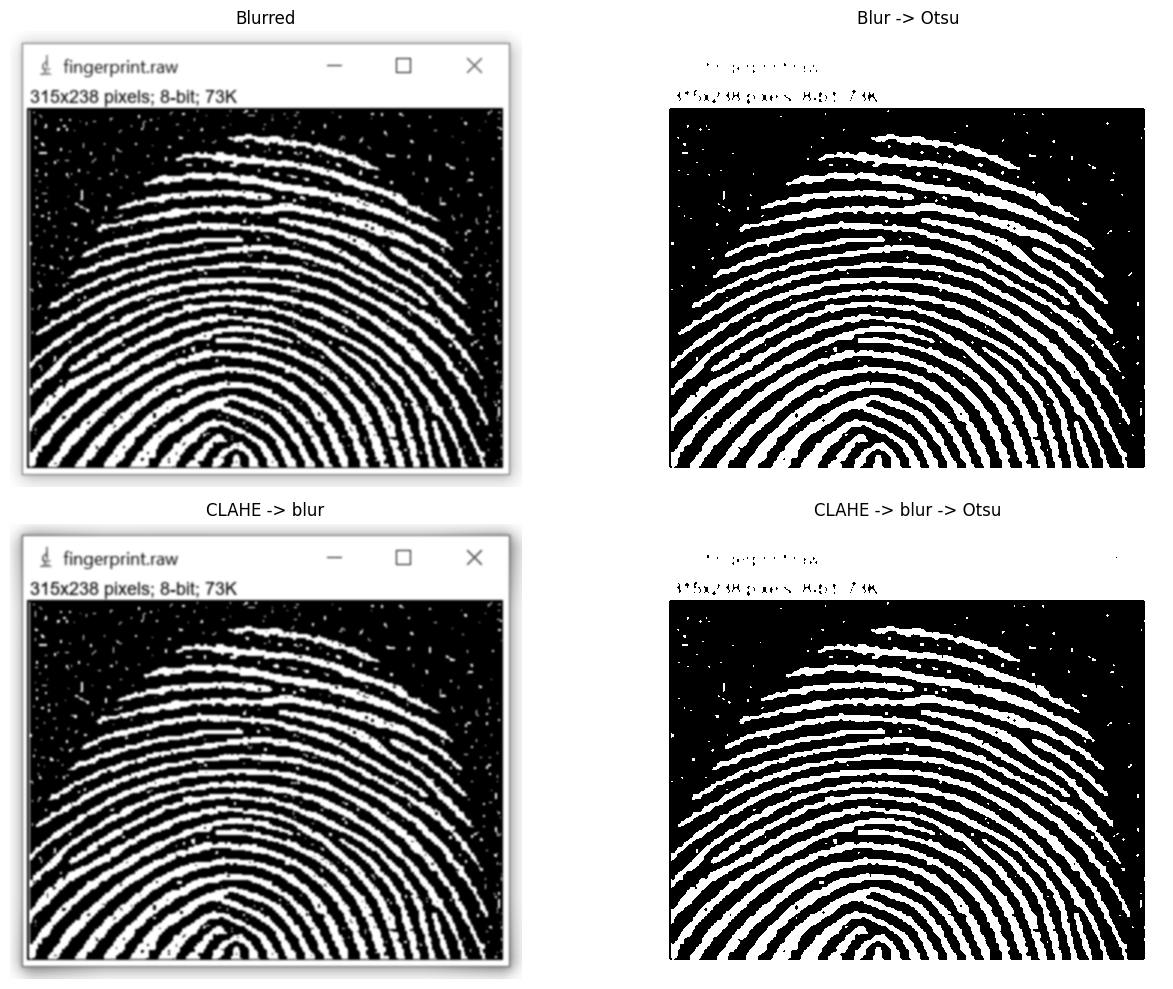

Challenge E: Document preprocessing pipeline


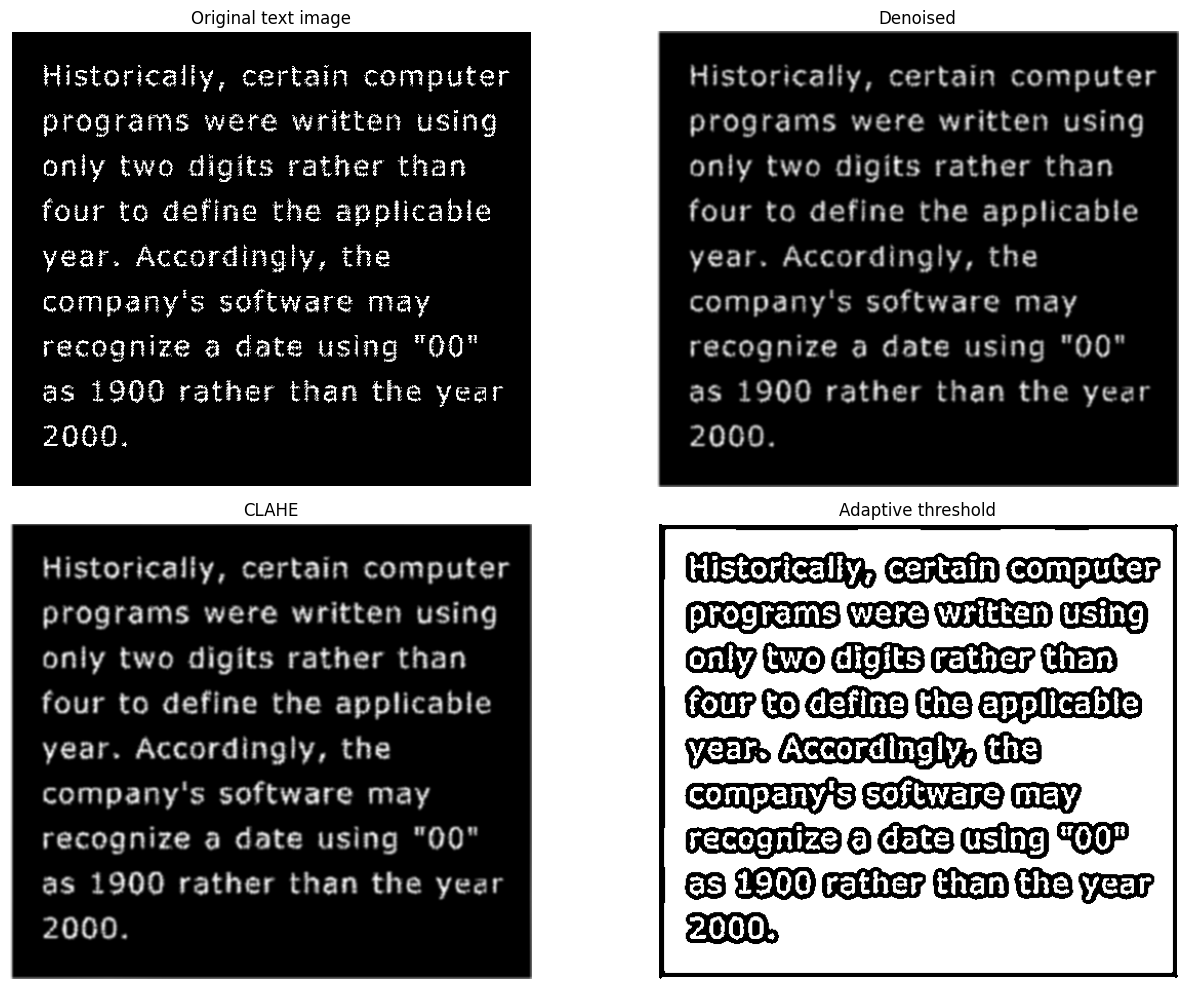

In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 8)

def resolve_image_path(image_name):
    current_directory = Path.cwd()
    for base_directory in [current_directory, *current_directory.parents]:
        candidate_path = base_directory / image_name
        if candidate_path.exists():
            return candidate_path
    raise FileNotFoundError(f"Could not find {image_name} in the current directory or any parent directory.")

def load_gray_image(image_name):
    image_path = resolve_image_path(image_name)
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Could not load {image_name} from {image_path}")
    return image

def show_images(images, titles, cols=2, figsize=(14, 8), cmap="gray"):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)
    for index, (image, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(rows, cols, index)
        if image.ndim == 2:
            plt.imshow(image, cmap=cmap)
        else:
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def make_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(image)

finger = load_gray_image("finger.png")
text_image = load_gray_image("text.png")

print("Challenge A: CLAHE versus global histogram equalization")
dark_finger = np.clip(finger * 0.35, 0, 255).astype(np.uint8)
global_equalized = cv2.equalizeHist(dark_finger)
clahe_a = make_clahe(dark_finger)
show_images(
    [dark_finger, global_equalized, clahe_a],
    ["Darkened image", "Global histogram equalization", "CLAHE"],
    cols=3,
    figsize=(16, 5)
 )

print("Challenge B: Gamma correction, log transform, and CLAHE on a dark image")
gamma_05 = np.clip(255.0 * np.power(dark_finger / 255.0, 0.5), 0, 255).astype(np.uint8)
log_input = dark_finger.astype(np.float32)
log_scale = 255 / np.log1p(log_input.max())
log_transformed = np.clip(log_scale * np.log1p(log_input), 0, 255).astype(np.uint8)
clahe_b = make_clahe(dark_finger)
show_images(
    [dark_finger, gamma_05, log_transformed, clahe_b],
    ["Darkened image", "Gamma 0.5", "Log transform", "CLAHE"],
    cols=2,
    figsize=(14, 10)
 )

print("Challenge C: CLAHE on grayscale, HSV-V, and LAB-L channels")
color_demo = cv2.applyColorMap(finger, cv2.COLORMAP_TURBO)
gray_demo = cv2.cvtColor(color_demo, cv2.COLOR_BGR2GRAY)
clahe_gray = make_clahe(gray_demo)

hsv_demo = cv2.cvtColor(color_demo, cv2.COLOR_BGR2HSV)
h_channel, s_channel, v_channel = cv2.split(hsv_demo)
v_clahe = make_clahe(v_channel)
hsv_clahe = cv2.cvtColor(cv2.merge((h_channel, s_channel, v_clahe)), cv2.COLOR_HSV2BGR)

lab_demo = cv2.cvtColor(color_demo, cv2.COLOR_BGR2LAB)
l_channel, a_channel, b_channel = cv2.split(lab_demo)
l_clahe = make_clahe(l_channel)
lab_clahe = cv2.cvtColor(cv2.merge((l_clahe, a_channel, b_channel)), cv2.COLOR_LAB2BGR)

show_images(
    [color_demo, clahe_gray, hsv_clahe, lab_clahe],
    ["Color demo image", "CLAHE on grayscale", "CLAHE on HSV-V", "CLAHE on LAB-L"],
    cols=2,
    figsize=(14, 10)
 )

print("Challenge D: Blur -> threshold versus CLAHE -> blur -> threshold")
blurred = cv2.GaussianBlur(finger, (5, 5), 0)
_, blur_threshold = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
clahe_for_threshold = make_clahe(finger)
clahe_blurred = cv2.GaussianBlur(clahe_for_threshold, (5, 5), 0)
_, clahe_threshold = cv2.threshold(clahe_blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
show_images(
    [blurred, blur_threshold, clahe_blurred, clahe_threshold],
    ["Blurred", "Blur -> Otsu", "CLAHE -> blur", "CLAHE -> blur -> Otsu"],
    cols=2,
    figsize=(14, 10)
 )

print("Challenge E: Document preprocessing pipeline")
document_denoised = cv2.GaussianBlur(text_image, (5, 5), 0)
document_enhanced = make_clahe(document_denoised)
document_adaptive = cv2.adaptiveThreshold(
    document_enhanced,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
 )
show_images(
    [text_image, document_denoised, document_enhanced, document_adaptive],
    ["Original text image", "Denoised", "CLAHE", "Adaptive threshold"],
    cols=2,
    figsize=(14, 10)
 )